# Introduction
Welcome to Lab 2, in this lab we will take our first steps into applying ML to satellite data, using landcover analysis as our primary goal.

As covered in Lecture 2, landcover classification is the quintessential remote sensing task in the civil sector. The LandSat programme (Lecture 3) was originally developed in large part to enable the USA to monitor landcover more easily for a range of agricultral, govermental and finacial problemsets. It remains a primary task for governments and companies around the world.

This is a pixel-wise ML task. We will apply two methods, both of which are available in GEE as ready-to-go algorithms. In this instance we are happy to go with built-in as it allows us to become familiar with an end-to-end GEE ML workflow without getting bogged down in technical detail. No need to re-invent the wheel unless you are going to the [moon](https://www.nasa.gov/feature/ames/artemis-moon-rover-s-wheels-are-ready-to-roll/).

Remember that this is a set of exercises and tutorials that escalate in difficulty. Always show your working and do not neccesarily expect to get full marks on everything.

Use the resources available to you outside of this material. I expect you to search for concepts or terms you do not understand and to look at the documentation of the code packages that we are using in the first instance of getting stuck. But do then of course ask us for help in the lab and on EdDiscussion.
_______________________________________________________________________________

# Set up

In [50]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same! (Downloaded on the 6th July)
## !pip install geemap --quiet

In [51]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='geog761-503611') #<- Remember to change this to your own project's name!

In [52]:
# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

# Define Area of Interest (AOI)

In [53]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [54]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

(1) What other mathematical [compositing](https://developers.google.com/earth-engine/guides/ic_composite_mosaic) approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)

= The alternative mathematical compositing approaches include the mean (average all pixel values can smooth data; however, it is sensitive to resideal outliers and or cloud contamination), minimum maximum (useful in terms of extracting specific extremes such as minimum surface reflectance cloud and or shadow influence), and Mode (which is most frequently occuring value in terms of being userful for categorical and or discrete data).

Use of following reference = https://www.tandfonline.com/doi/full/10.1080/10095020.2025.2542534#d1e340

In [55]:
# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map = geemap.Map(center=[-41.3, 174.75], zoom=11) #<- reset the map object to clear out other layers from earlier cells
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

________________________________________________________________________________

# Training data

We are going to train our data using the European Space Agency (ESA) world landcover map. Given that this is derived from satellite data our logic is at risk of becoming a little circular here. But as a training exercise it is a good way to have easy to access training data of the right size and type to apply to our image.

There are a wide range of landcover datasets in the GEE catalogue that you can use for this purpose:
*   https://developers.google.com/earth-engine/datasets/tags/landuse-landcover

First, we will load in the landcover map we will use to create our training dataset (https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100):



Next we need to use our landcover map to [sample](https://developers.google.com/earth-engine/apidocs/ee-image-sample) the Sentinel 2 image, associating each pixel of a given landcover with the spectral band values 'beneath' it.

In [56]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Need to change this to sequential list to avoid the algs thiniing there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

= The year in which the landcover map was created was in 2020.

In [57]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped).addBands(landcover_remapped)

Let's inspect the resulting training dataset and make sure that you understand what you have built here.

We are going to:
- Print the first few rows (client-side).
- Check the number of samples per class (server-side with reduceColumns).

This may take a little time to run as we request data both client and server side.

In [58]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())



First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3140000104904175
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)

= Since sample 2 has class = 8, which corresponds to ESA WorldCovers 'permanent water bodies' category, this is consistent with the spectral values shown of B8 (NIR), which is very low relative to the visible bands, since water strongly absorbs near infrared light.

We are now ready to start machine learning on classifying the landcover of Wellington!
________________________________________________________________________________

# Random Forest Classification for Landcover
Let us do machine learning properly and first apply a 70/20/10 split that allows us to produce some accuracy statistics.

In [59]:
# Add random column
sample = sample.randomColumn('random')

# Split
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Our next task is to set up a classifier object, followed by applying it to the image using the .classify operator. This operator hides a LOT of behind the scenes plumbing from Google.

We use the [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest) model that they have pre-built for us. Specifying the number of trees to use is the only variable we must set. Othe variables are available, read the docs!

In [60]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

With the model trained, we just apply it simply using the '.classify' operator.

In [61]:
# Classify image
classified = s2.select(bands).classify(classifier)

Let's visualize what we have just made!

In [62]:
# Classified image viz, fresh set up again to make sure we have exactly what we want displayed.
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(classified.randomVisualizer(), {}, 'Classified')
Map.addLayer(landcover_remapped.randomVisualizer(), {} ,'ESA Landcover')
Map

Map(center=[-41.300046246343555, 174.75000000000097], controls=(WidgetControl(options=['position', 'transparen…

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

= When comparing the two maps, the random forest classification differs primarily in areas with transitional land cover (such as grassland bordering shrubland or cropland), potentially due to spectral band overlap between classes across four bands (B2, B3, B4, B8). The training data was also quite imbalanced across classes: for instance, class 4 had only 1 sample and class 2 had only 6, compared to 2600 for class 8, meaning the classifier had very little data to learn from for rare classes, leading to misclassification in those areas. There also may be a temporal mismatch since ESA WorldCover 2020 is a rather fixed annual product, while Sentinel 2 compositing depends on the specific date range and on the cloud filtering choices made. Lastly, the randomVisualizer() assigns colours randomly each time it is rendered, so differing colours between the two maps do not necessarily indicate different class assignments.

Finally, we will apply our test data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall) that we need to make smart choices about our training approach.

In [63]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Validate
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Pretty-print
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       230        1       31        0        2        0        0   
Actual 20         1        0        0        0        0        0        0   
Actual 30        39        0      154        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        3        0       23        2        0   
Actual 60         0        0        1        0        2        1        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        6        0        0   
Actual 90         0        0        3        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:

> Add blockquote


*   Landcover maps of Wellington for 2018, 2022 and 2024
*   The Test accuracy averages of the RF classifier for 2020.
*   Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.
  
(15 pts)
_______________________________________________________________________________


In [64]:
# Reusing previous lines of code no.1
# Wrapping the composite building logic into a function so it can be reused for any years date range
def get_s2_composite(start_date, end_date):
    s2_year = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
               .filterBounds(aoi) # Restricting to Wellington AOI
               .filterDate(start_date, end_date) # Applying filter to the given years date range
               .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))  # Dropping the very cloudy scenes
               .map(mask_s2_clouds) # Applying per pixel cloud mask
               .median())  # Compositing into one cloud free image
    return s2_year
# Building composites for each comparison year using the same method as the original 2020 composite
s2_2018 = get_s2_composite('2018-01-01', '2018-12-31')
s2_2022 = get_s2_composite('2022-01-01', '2022-12-31')
s2_2024 = get_s2_composite('2024-01-01', '2024-12-31')

In [65]:
# Reassuring that each year is classified with the existing classifier, applying the same classifier trained on 2020 data to each new year's composite (no retraining)
classified_2018 = s2_2018.select(bands).classify(classifier)
classified_2022 = s2_2022.select(bands).classify(classifier)
classified_2024 = s2_2024.select(bands).classify(classifier)

In [66]:
# Obtaining the 2020 test accuracy, classifying the held out test set (not the validation set) using the trained classifier
tested = test.classify(classifier, 'predicted')
# Pulling actual vs predicted labels down to local lists for scoring
y_true_test, y_pred_test = fc_to_lists(tested, 'Map_remapped', 'predicted')
# Computing the precision/recall/F1/accuracy across all 10 classes
test_report = classification_report(y_true_test, y_pred_test, labels=list(range(1, 11)), output_dict=True)
# Extracting just the overall accuracy figure to use in the final report
overall_accuracy = test_report['accuracy']

{1: 'Tree cover', 2: 'Shrubland', 3: 'Grassland', 4: 'Cropland', 5: 'Built-up', 6: 'Bare/sparse vegetation', 7: 'Snow and ice', 8: 'Permanent water bodies', 9: 'Herbaceous wetland', 10: 'Moss and lichen'}


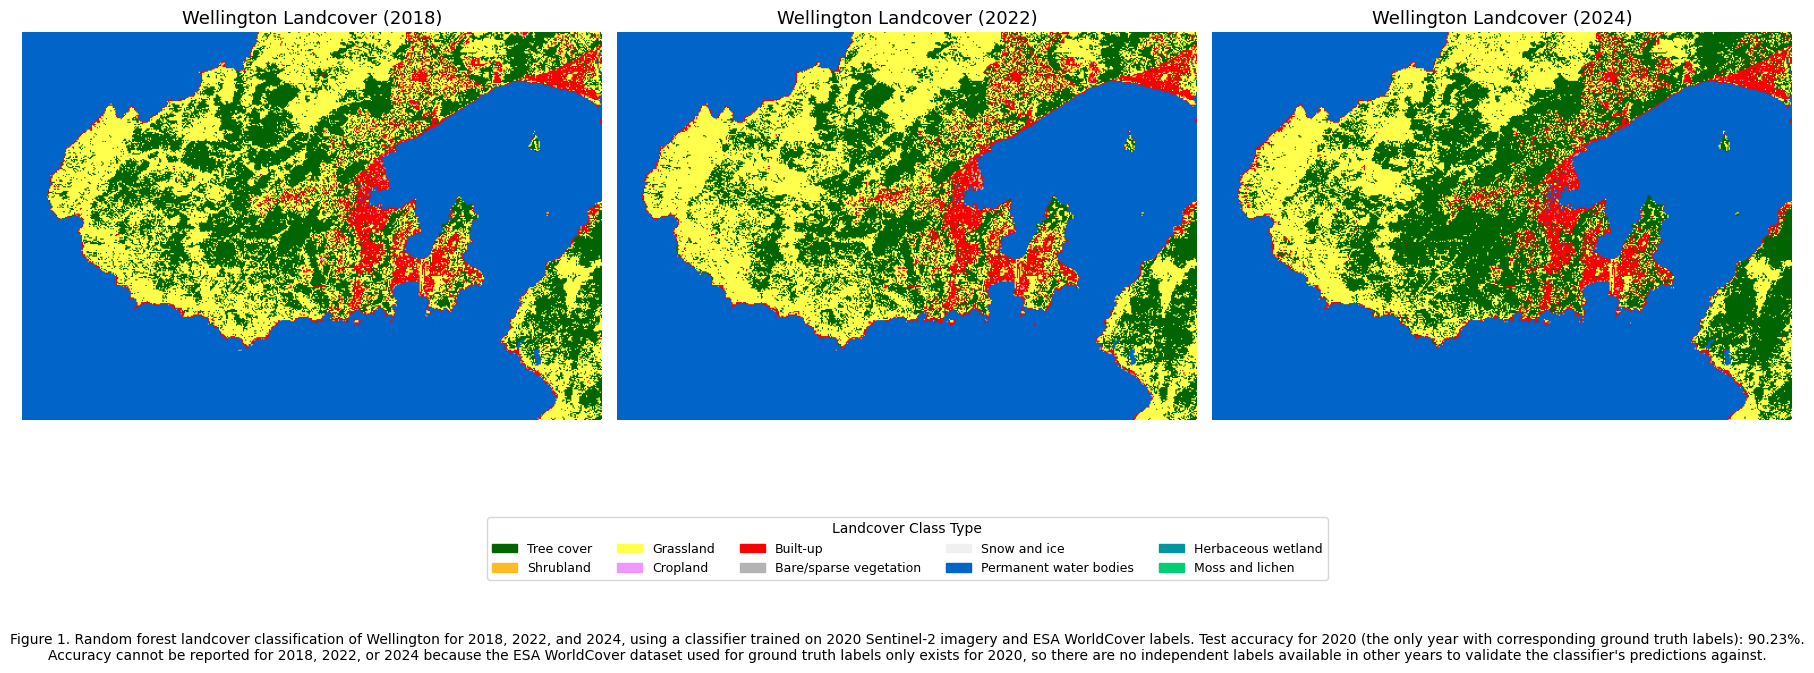

In [67]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import image as mpimg
import urllib.request
import io

# Ensuring label_map uses real ESA WorldCover class names, not raw codes. Class names/codes sourced from the ESA WorldCover v100 Product User Manual
esa_class_names = {
    1: 'Tree cover',
    2: 'Shrubland',
    3: 'Grassland',
    4: 'Cropland',
    5: 'Built-up',
    6: 'Bare/sparse vegetation',
    7: 'Snow and ice',
    8: 'Permanent water bodies',
    9: 'Herbaceous wetland',
    10: 'Moss and lichen'
}
label_map = esa_class_names

# Confirming real class names before building the legend
print(label_map)  # Should print output of {1: 'Tree cover', 2: 'Shrubland', etc}

# Building an ordered list of class names matching the 1 to 10 remapped class indices
class_names = [label_map[i + 1] for i in range(10)]

# Visualization params (fixed palette in order for colors match across years). A hex color assigned to each class, ordered to match class_names above
class_palette = [
    '006400',  # 1 Tree cover
    'ffbb22',  # 2 Shrubland
    'ffff4c',  # 3 Grassland
    'f096ff',  # 4 Cropland
    'fa0000',  # 5 Built-up
    'b4b4b4',  # 6 Bare/sparse vegetation
    'f0f0f0',  # 7 Snow and ice
    '0064c8',  # 8 Permanent water bodies
    '0096a0',  # 9 Herbaceous wetland
    '00cf75'   # 10 Moss and lichen
]
# Min and max defining the class value range, palette maps each value to a color
vis_params = {
    'min': 1,
    'max': 10,
    'palette': class_palette
}

# Using a Function to fetch a thumbnail as a numpy array, in which requests a rendered PNG thumbnail of an Earth Engine image and loads it into memory
def get_thumb_array(image, region, vis_params, dimensions=512):
    url = image.getThumbURL({
        **vis_params,
        'region': region,
        'dimensions': dimensions,
        'format': 'png'
    })
    with urllib.request.urlopen(url) as response:
        img_data = response.read()
    return mpimg.imread(io.BytesIO(img_data), format='png')

# Pulling each classified year as an array
img_2018 = get_thumb_array(classified_2018, aoi, vis_params)
img_2022 = get_thumb_array(classified_2022, aoi, vis_params)
img_2024 = get_thumb_array(classified_2024, aoi, vis_params)

# Looping through each years image and display it in its own subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

years_imgs = [('2018', img_2018), ('2022', img_2022), ('2024', img_2024)]

for ax, (year, img) in zip(axes, years_imgs):
    ax.imshow(img)
    ax.set_title(f'Wellington Landcover ({year})', fontsize=13)
    ax.axis('off')

# Creating a shared lebeled legend, building one legend patch per class that is shared across all three subplots
legend_patches = [
    mpatches.Patch(color=f'#{c}', label=n)
    for c, n in zip(class_palette, class_names)
]

fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=5,  # drop to ncol=2 if labels wrap awkwardly
    bbox_to_anchor=(0.5, -0.1),
    fontsize=9,
    title='Landcover Class Type'
)

# Adding figure Caption (embedding the 2020 test accuracy as required for the exercise, and explaining why other years' accuracy cannot be reported)
caption = (
    f"Figure 1. Random forest landcover classification of Wellington for 2018, 2022, and 2024, using a classifier trained on 2020 Sentinel-2 imagery and ESA WorldCover labels. "
    f"Test accuracy for 2020 (the only year with corresponding ground truth labels): {overall_accuracy:.2%}. Accuracy cannot be reported for 2018, 2022, or 2024 because the ESA WorldCover dataset used for "
    f"ground truth labels only exists for 2020, so there are no independent labels available in other years to validate the classifier's predictions against."
)

fig.text(0.5, -0.22, caption, wrap=True, ha='center', fontsize=10)

plt.tight_layout() # Adjusting spacing so subplots/legend/caption do not overlap
plt.savefig('wellington_landcover_multiyear.png', dpi=300, bbox_inches='tight')
plt.show()

## Reference link to the use of 'getThumbURL' = https://developers.google.com/earth-engine/apidocs/ee-image-getthumburl
## AReference link to the use of "esa_class_names" = https://esa-worldcover.s3.eu-central-1.amazonaws.com/v100/2020/docs/WorldCover_PUM_V1.0.pdf

In [68]:
# Exporting the map figure as a JPG file and downloading it
from google.colab import files

fig.savefig('wellington_landcover_multiyear.jpg', dpi=300, bbox_inches='tight', format='jpg')

# Triggering a download prompt in the browser
files.download('wellington_landcover_multiyear.jpg')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# SVMs Applied to Satellite Data

In [69]:
# Define and train the SVM classifier
class_property = 'Map_remapped'
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train,
    classProperty=class_property,
    inputProperties=bands
)

# Classify validation and test sets
val_classified = valid.classify(svm)
test_classified = test.classify(svm)

# Evaluate test performance
test_matrix = test_classified.errorMatrix(class_property, 'classification')
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       230        1       31        0        2        0        0   
Actual 20         1        0        0        0        0        0        0   
Actual 30        39        0      154        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        3        0       23        2        0   
Actual 60         0        0        1        0        2        1        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        6        0        0   
Actual 90         0        0        3        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



In [70]:
# Uploading the LCDB v5.0 zip file
import zipfile
import geopandas as gpd

# Uploading the ZIP manually using the Colab UI
from google.colab import files
uploaded = files.upload()

# Unzipping the file (renamed downloaded file before unzipping)
with zipfile.ZipFile("LCDB_v5.zip", 'r') as zip_ref:
    zip_ref.extractall("lcdb")

# Reading shapefile
gdf = gpd.read_file("lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp")
print(gdf.head())


Saving LCDB_v5.zip to LCDB_v5 (1).zip
           Name_2018          Name_2012          Name_2008          Name_2001  \
0  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   
1     Sand or Gravel     Sand or Gravel     Sand or Gravel     Sand or Gravel   
2  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   
3     Sand or Gravel     Sand or Gravel     Sand or Gravel     Sand or Gravel   
4  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   

           Name_1996  Class_2018  Class_2012  Class_2008  Class_2001  \
0  Indigenous Forest          69          69          69          69   
1     Sand or Gravel          10          10          10          10   
2  Indigenous Forest          69          69          69          69   
3     Sand or Gravel          10          10          10          10   
4  Indigenous Forest          69          69          69          69   

   Class_1996  ... Wetland_96 Onshore_18 O

In [71]:
# LCDB is provided in NZTM (EPSG:2193), reprojecting to WGS84 (EPSG:4326)
gdf = gdf.to_crs(epsg=4326)
print(gdf.crs) # Confirming whether reprojection worked
print(gdf.total_bounds) # Checking whether the extent matches with Great Barrier Islands coordinates

## Reference link to the use of reprojection = https://geopandas.org/en/stable/docs/user_guide/projections.html

EPSG:4326
[175.28179689 -36.34920981 175.55101253 -36.02511126]


In [72]:
import ee
# Defining the Great Barrier Island bounding box based on the reprojected data extent
aoi_gbi = ee.Geometry.Rectangle([175.28, -36.35, 175.55, -36.03])
# Checking which LCDB landcover classes are present in this particular region
print(gdf['Name_2018'].value_counts())

# Dropping any polygons with missing or invalid geometry
gdf = gdf[gdf.geometry.notnull()]
gdf = gdf[gdf.is_valid]

Name_2018
Indigenous Forest                            107
Sand or Gravel                                90
Broadleaved Indigenous Hardwoods              83
Manuka and/or Kanuka                          77
High Producing Exotic Grassland               54
Low Producing Grassland                       31
Exotic Forest                                 26
Herbaceous Saline Vegetation                  14
Built-up Area (settlement)                    10
Mangrove                                       8
Gorse and/or Broom                             7
Herbaceous Freshwater Vegetation               5
Orchard, Vineyard or Other Perennial Crop      4
Urban Parkland/Open Space                      3
Lake or Pond                                   2
Gravel or Rock                                 2
River                                          2
Estuarine Open Water                           2
Forest - Harvested                             2
Surface Mine or Dump                           1
Landslide 

In [73]:
import geemap
# Keeping only the columns needed for training
gdf_clean = gdf[['geometry', 'Class_2018', 'Name_2018']].copy()
# Converting the GeoDataFrame into an Earth Engine FeatureCollection
lcdb_fc = geemap.geopandas_to_ee(gdf_clean)



In [74]:
# Building a cloud-masked Sentinel-2 median composite over the AOI, for the Austral summer spanning December 2018 to Feb 2019
s2_gbi_2018_19 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                   .filterBounds(aoi_gbi) # Restricting to Great Barrier Island
                   .filterDate('2018-12-01', '2019-02-28')  # Austral summer date range
                   .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) # Dropping very cloudy scenes
                   .map(mask_s2_clouds) # Applying per pixel cloud mask
                   .median())  # Composite into one cloud-free image

print(s2_gbi_2018_19.bandNames().getInfo()) # Checking the expected bands

['B2', 'B3', 'B4', 'B8']


In [75]:
# Converting the LCDB polygons into a labeled raster image (1 class code per pixel)
lcdb_image = lcdb_fc.reduceToImage(
    properties=['Class_2018'],
    reducer=ee.Reducer.first()
).rename('landcover')

# Stacking the S2 bands with the landcover label band
stacked = s2_gbi_2018_19.select(bands).addBands(lcdb_image)

# Creating a set of training points, capped per class, to avoid huge or imbalanced sampling
training_gbi = stacked.stratifiedSample(
    numPoints=500, # max points per class
    classBand='landcover',
    scale=10, # Sentinel-2 pixel resolution in meters
    region=aoi_gbi, # breaking computation into smaller tiles to avoid server timeouts
    tileScale=16,
    geometries=True
)

print(training_gbi.size().getInfo()) # Revealing total number of sampled training points


## Reference link to the use of 'reduceToImage' = https://developers.google.com/earth-engine/apidocs/ee-featurecollection-reducetoimage
## Reference link to the use of 'stratifiedSample' = https://developers.google.com/earth-engine/apidocs/ee-image-stratifiedsample

9763


In [76]:
# Adding a random column, then split 70/30 into training and test sets
training_gbi = training_gbi.randomColumn()
train_gbi = training_gbi.filter(ee.Filter.lt('random', 0.7))
test_gbi = training_gbi.filter(ee.Filter.gte('random', 0.7))

print('Train:', train_gbi.size().getInfo())
print('Test:', test_gbi.size().getInfo())

Train: 6831
Test: 2932


In [77]:
import numpy as np
# Converting Earth Engine FeatureCollections into local pandas DataFrames
train_df = geemap.ee_to_df(train_gbi)
test_df = geemap.ee_to_df(test_gbi)
# Splitting into feature matrix (X) and label vector (y) for training and testing
X_train = train_df[bands].values
y_train = train_df['landcover'].values
X_test = test_df[bands].values
y_test = test_df['landcover'].values

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (6831, 4) Test shape: (2932, 4)


In [78]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Building a pipeline that scales features (mean 0, std 1) before feeding into an RBF kernel SVM
svm_sklearn = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale'))
svm_sklearn.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC())])

In [79]:
from sklearn.metrics import accuracy_score, classification_report
# Predicting on the held out test set and report accuracy + per class performance
y_pred = svm_sklearn.predict(X_test)
print("SVM Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

SVM Test Accuracy: 0.44236016371077763
              precision    recall  f1-score   support

           1       0.39      0.36      0.37       158
           2       0.73      0.57      0.64       169
           5       0.46      0.65      0.53       110
           6       0.71      0.68      0.70        59
          10       0.44      0.21      0.28       148
          12       0.00      0.00      0.00        23
          16       0.43      0.47      0.45       154
          20       1.00      0.26      0.41        31
          21       0.55      0.48      0.51       147
          22       0.74      0.87      0.80       145
          33       0.37      0.49      0.42       135
          40       0.37      0.47      0.41       149
          41       0.37      0.08      0.13       172
          45       0.38      0.41      0.39       151
          46       0.49      0.51      0.50       162
          51       0.38      0.51      0.44       140
          52       0.26      0.23      0.2

In [80]:
# Computing the same mean/std used by StandardScaler, to then proceed in replicating the scaling manually when classifying the full image server side through Earth Engine
means = train_df[bands].mean()
stds = train_df[bands].std()

print(means)
print(stds)

B2    0.047498
B3    0.071759
B4    0.063760
B8    0.251927
dtype: float64
B2    0.037888
B3    0.042277
B4    0.049848
B8    0.101208
dtype: float64


In [81]:
means_dict = means.to_dict()
stds_dict = stds.to_dict()
# Applying (value - mean) / std to each band of each training feature, matching what StandardScaler did client side
def normalize_feature(feature):
    normalized = {b: ee.Number(feature.get(b)).subtract(means_dict[b]).divide(stds_dict[b]) for b in bands}
    return feature.set(normalized)

train_gbi_norm = train_gbi.map(normalize_feature)

In [82]:
# Training an Earth Engine SVM classifier on the normalized training data, using hyperparameters chosen to roughly match the sklearn run for comparability
svm_classifier_final = ee.Classifier.libsvm(
    kernelType='RBF',
    gamma=0.5,
    cost=1.0
).train(
    features=train_gbi_norm,
    classProperty='landcover',
    inputProperties=bands
)

In [83]:
# Building constant images representing the per-band mean/std in order the whole image can be normalized the same way the training data was
mean_image = ee.Image.constant([means_dict[b] for b in bands]).rename(bands)
std_image = ee.Image.constant([stds_dict[b] for b in bands]).rename(bands)

# Normalizing the full stacked image, then classify every pixel
stacked_norm = stacked.select(bands).subtract(mean_image).divide(std_image)
classified_gbi_final = stacked_norm.classify(svm_classifier_final)

print(classified_gbi_final.bandNames().getInfo())  # sanity checks of the classification band exists

['classification']


In [84]:
# Checking which class codes actually appear in the training data
unique_classes = train_df['landcover'].unique()
print(sorted(unique_classes))

[np.int64(1), np.int64(2), np.int64(5), np.int64(6), np.int64(10), np.int64(12), np.int64(16), np.int64(20), np.int64(21), np.int64(22), np.int64(33), np.int64(40), np.int64(41), np.int64(45), np.int64(46), np.int64(51), np.int64(52), np.int64(54), np.int64(64), np.int64(69), np.int64(70), np.int64(71)]


In [85]:
# Buildng a lookup from class code -> readable class name, using the original gdf
class_lookup = gdf.drop_duplicates('Class_2018')[['Class_2018', 'Name_2018']].set_index('Class_2018')['Name_2018'].to_dict()
for code in sorted(unique_classes):
    print(code, '-', class_lookup.get(code, 'Unknown'))

1 - Built-up Area (settlement)
2 - Urban Parkland/Open Space
5 - Transport Infrastructure
6 - Surface Mine or Dump
10 - Sand or Gravel
12 - Landslide
16 - Gravel or Rock
20 - Lake or Pond
21 - River
22 - Estuarine Open Water
33 - Orchard, Vineyard or Other Perennial Crop
40 - High Producing Exotic Grassland
41 - Low Producing Grassland
45 - Herbaceous Freshwater Vegetation
46 - Herbaceous Saline Vegetation
51 - Gorse and/or Broom
52 - Manuka and/or Kanuka
54 - Broadleaved Indigenous Hardwoods
64 - Forest - Harvested
69 - Indigenous Forest
70 - Mangrove
71 - Exotic Forest


In [86]:
# Manually assigning a name and color to each class code, ordered to match sorted(unique_classes)
class_info = [
    (1,  'Built-up Area (settlement)',              'd7191c'),  # red
    (2,  'Urban Parkland/Open Space',                'fdae61'),  # orange
    (5,  'Transport Infrastructure',                 '808080'),  # grey
    (6,  'Surface Mine or Dump',                      '4d4d4d'),  # dark grey
    (10, 'Sand or Gravel',                             'f0e68c'),  # khaki
    (12, 'Landslide',                                   'bdb76b'),  # dark khaki
    (16, 'Gravel or Rock',                              'c2b280'),  # sand
    (20, 'Lake or Pond',                                '2b83ba'),  # blue
    (21, 'River',                                       '5fa3d9'),  # light blue
    (22, 'Estuarine Open Water',                        '0868ac'),  # dark blue
    (33, 'Orchard, Vineyard or Other Perennial Crop',   'ffff99'),  # pale yellow
    (40, 'High Producing Exotic Grassland',             'ffeb3b'),  # yellow
    (41, 'Low Producing Grassland',                     'd4e157'),  # yellow-green
    (45, 'Herbaceous Freshwater Vegetation',            '80cdc1'),  # teal
    (46, 'Herbaceous Saline Vegetation',                '35978f'),  # dark teal
    (51, 'Gorse and/or Broom',                          '8c510a'),  # brown
    (52, 'Manuka and/or Kanuka',                        'bf812d'),  # tan brown
    (54, 'Broadleaved Indigenous Hardwoods',            '1b7837'),  # green
    (64, 'Forest - Harvested',                          '762a83'),  # purple
    (69, 'Indigenous Forest',                           '006837'),  # dark green
    (70, 'Mangrove',                                     '01665e'),  # dark teal-green
    (71, 'Exotic Forest',                                '5aae61'),  # medium green
]

class_codes = [c[0] for c in class_info]
class_names = [c[1] for c in class_info]
class_colors = [c[2] for c in class_info]

print(len(class_codes), 'classes')

22 classes


In [87]:
# LCDB class codes are not sequential, so remap them to 0..N-1 purely for color visualization
remap_from = class_codes
remap_to = list(range(len(class_codes)))
classified_gbi_vis = classified_gbi_final.remap(remap_from, remap_to, bandName='classification')

# Defining the color palette for visualization
vis_params_gbi = {
    'min': 0,
    'max': len(class_codes) - 1,
    'palette': class_colors
}

# Clipping the classified image to the actual island landmass, so ocean pixels are not force classified into a land category
island_land_geom = lcdb_fc.geometry()
classified_gbi_vis_clipped = classified_gbi_vis.clip(island_land_geom)
# Pulling the clipped, colored classification as a local image array for plotting
img_gbi_classified_clipped = get_thumb_array(classified_gbi_vis_clipped, aoi_gbi, vis_params_gbi, dimensions=512)

In [88]:
# Calculating the true geodesic distance across the AOI (in km) using the haversine formula, rather than a rough degrees to km approximation, so the maps scale bar is accurate.
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):
    # Converting decimal degrees to radians, as required by the trig functions below
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2 # Haversine formula computes greater circle distance between two lat/lon points
    return 2 * 6371 * asin(sqrt(a))  # 6371 = Earths mean radius in km, result returns in km

# Using the AOI's (Great Barrier Island) longitude bounds and mid latitude to measure its real world width
lon_min, lon_max = 175.28, 175.55
lat_mid = (-36.35 + -36.03) / 2
# Computing the real width of the AOI in kilometers, used later to build an accurate scale bar to then add onto the map figure
real_width_km = haversine(lon_min, lat_mid, lon_max, lat_mid)
print(f"Real AOI width: {real_width_km:.2f} km")

Real AOI width: 24.23 km


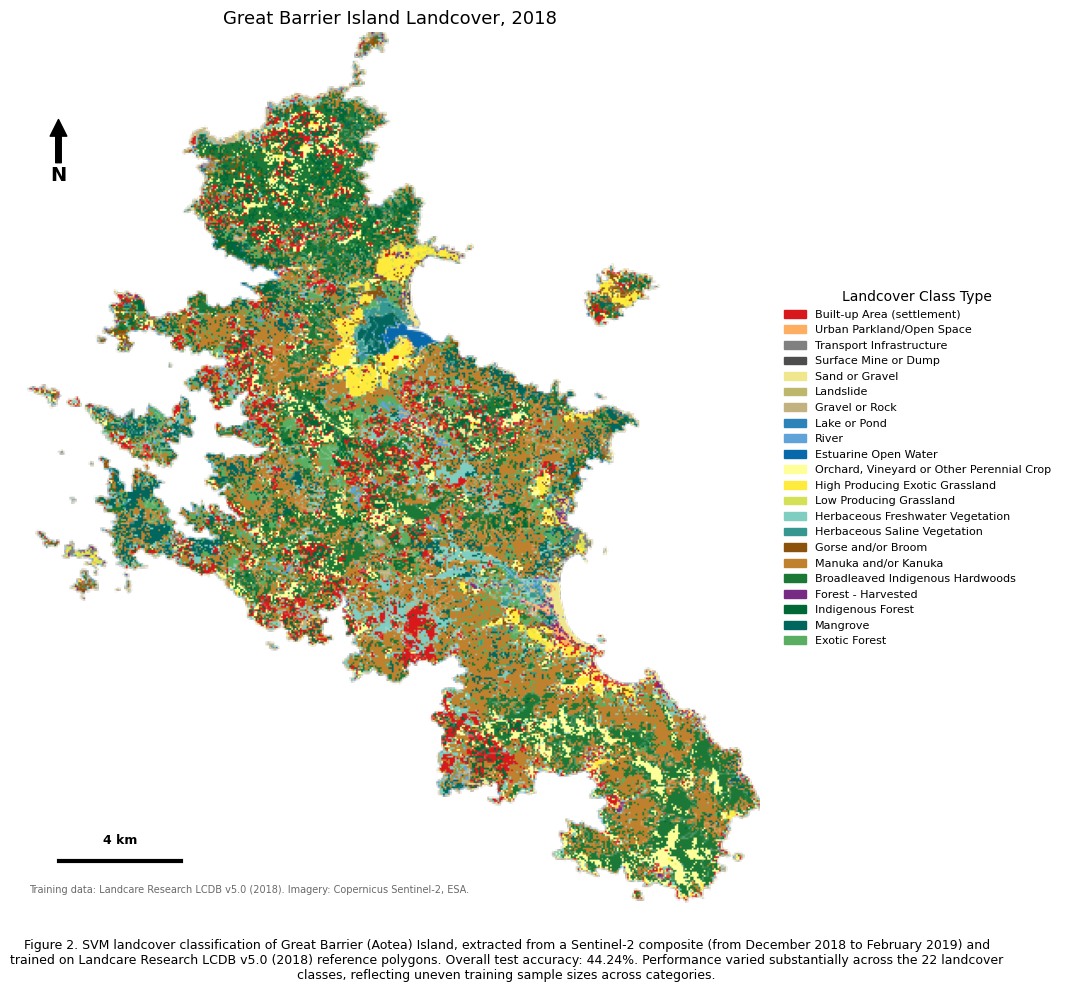

In [89]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 10))

# Displaying the classified island map
ax.imshow(img_gbi_classified_clipped)
ax.set_title('Great Barrier Island Landcover, 2018', fontsize=13)
ax.axis('off')

img_h, img_w = img_gbi_classified_clipped.shape[0], img_gbi_classified_clipped.shape[1]

# Building a legend using the class names/colors defined earlier
legend_patches = [mpatches.Patch(color=f'#{c}', label=n) for c, n in zip(class_colors, class_names)]
ax.legend(
    handles=legend_patches,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    title='Landcover Class Type',
    frameon=False
)

# Adding a North arrow to the map figure
ax.annotate('N', xy=(0.05, 0.90), xytext=(0.05, 0.83),
            xycoords='axes fraction',
            fontsize=14, fontweight='bold', ha='center',
            arrowprops=dict(facecolor='black', width=4, headwidth=12))

# Adding scale bar to map figure
km_per_pixel = real_width_km / img_w   # using precise geodesic distance from the haversine calculation

scale_km = 4  # 4 km scale bar
scale_px = scale_km / km_per_pixel

bar_x_start = img_w * 0.05
bar_y = img_h * 0.95
ax.plot([bar_x_start, bar_x_start + scale_px], [bar_y, bar_y], color='black', linewidth=3)
ax.text(bar_x_start + scale_px / 2, bar_y - img_h * 0.02, f'{scale_km} km',
        ha='center', fontsize=9, fontweight='bold')

# Adding data source attribution into the map figure
ax.text(0.01, 0.01,
        'Training data: Landcare Research LCDB v5.0 (2018). Imagery: Copernicus Sentinel-2, ESA.',
        transform=ax.transAxes, fontsize=7, color='dimgray', va='bottom')

# Adding figure caption
caption = (
    f"Figure 2. SVM landcover classification of Great Barrier (Aotea) Island, extracted from a Sentinel-2 "
    f"composite (from December 2018 to February 2019) and trained on Landcare Research LCDB v5.0 (2018) reference polygons. "
    f"Overall test accuracy: {accuracy_score(y_test, y_pred):.2%}. Performance varied substantially across the 22 landcover classes, reflecting uneven training sample sizes across categories."
)
fig.text(0.5, -0.02, caption, wrap=True, ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('great_barrier_island_landcover.png', dpi=300, bbox_inches='tight')
plt.show()

## Reference link to using 'matplotlib.pyplot.legend' = https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html
## Reference link to using 'matplotlib.pyplot.annotate' = https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html

In [90]:
# Exporting the map figure as a JPG file and downloading it
from google.colab import files

fig.savefig('great_barrier_island_landcover.jpg', dpi=300, bbox_inches='tight', format='jpg')
# Triggering a download prompt in the browser
files.download('great_barrier_island_landcover.jpg')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>